In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,AdaBoostClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score,precision_score,recall_score,f1_score
from sklearn.preprocessing import StandardScaler,OneHotEncoder

In [2]:
data=pd.read_excel("Term deposit train data.csv.xlsx")
data['poutcome'].value_counts()


poutcome
unknown    36959
failure     4901
other       1840
success     1511
Name: count, dtype: int64

In [3]:
print(data.info())
data.isnull().sum().sort_index(ascending=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB
None


y            0
previous     0
poutcome     0
pdays        0
month        0
marital      0
loan         0
job          0
housing      0
education    0
duration     0
default      0
day          0
contact      0
campaign     0
balance      0
age          0
dtype: int64

In [4]:
df=data[["age","balance","duration","campaign","pdays","previous"]]
for i in df.columns:
    Q3=df[i].quantile(0.75)
    Q1=df[i].quantile(0.25)
    IQR=Q3-Q1
    lower_bound=Q1-1.5*IQR
    upper_bound=Q3+1.5*IQR
    outliers=data[(df[i]<lower_bound)|(df[i]>upper_bound)]
    print(outliers)
    print(lower_bound,upper_bound)

       age      job   marital  education default  balance housing loan  \
7239    71  retired   married    primary      no        0      no   no   
7240    71  retired  divorced  secondary      no        0      no   no   
7241    72  retired   married   tertiary      no        0      no   no   
7242    72  retired  divorced    primary      no        0      no   no   
7243    72  retired   married  secondary      no        0      no   no   
...    ...      ...       ...        ...     ...      ...     ...  ...   
45154   77  retired   married    primary      no    29340      no   no   
45158   71  retired   married  secondary      no    29941      no   no   
45176   75  retired  divorced    primary      no    37127      no   no   
45207   84  retired   married  secondary      no    81204      no   no   
45208   84  retired   married  secondary      no    81204      no   no   

         contact  day month  duration  campaign  pdays  previous poutcome    y  
7239    cellular   16   sep   

In [5]:
for i in df.columns:
    mean=df[i].mean()
    sd=df[i].std()
    z=(df[i]-mean)/sd
    outliers=data[abs(z)>3]
    print(outliers)

       age      job   marital  education default  balance housing loan  \
7247    74  retired   married    primary      no        0      no   no   
7248    74  retired   married    primary      no        0      no   no   
7249    74  retired   married    primary      no        0      no   no   
7250    76  retired   married   tertiary      no        0      no   no   
7251    76  retired   married   tertiary      no        0      no   no   
...    ...      ...       ...        ...     ...      ...     ...  ...   
45148   74  retired  divorced    primary      no    29080      no   no   
45154   77  retired   married    primary      no    29340      no   no   
45176   75  retired  divorced    primary      no    37127      no   no   
45207   84  retired   married  secondary      no    81204      no   no   
45208   84  retired   married  secondary      no    81204      no   no   

         contact  day month  duration  campaign  pdays  previous poutcome    y  
7247   telephone   13   aug   

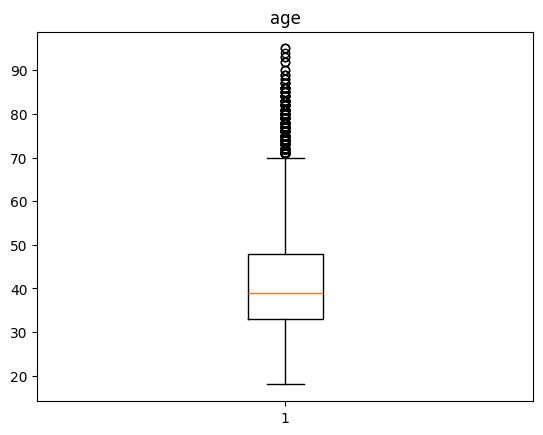

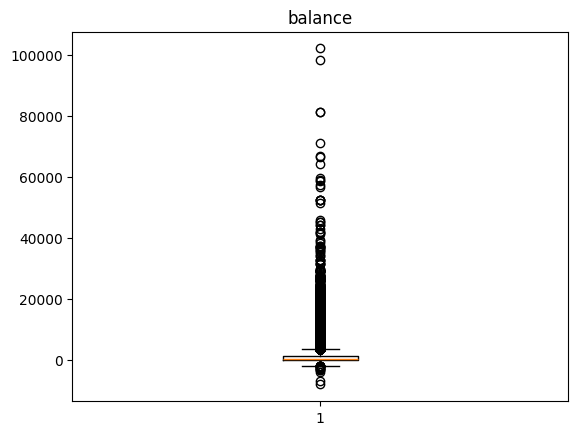

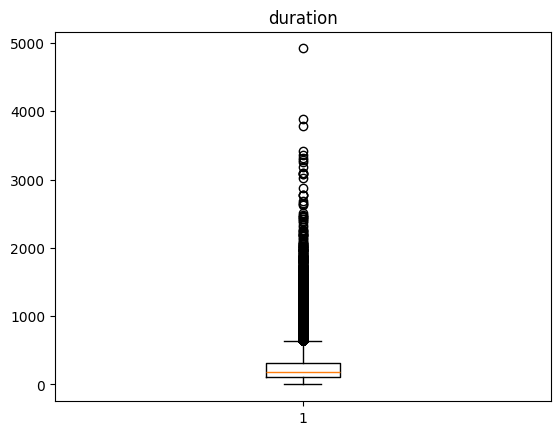

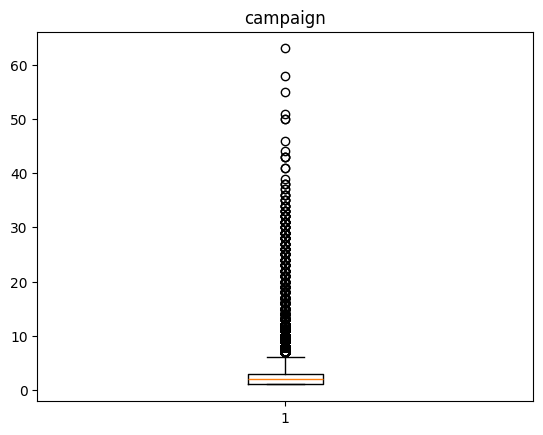

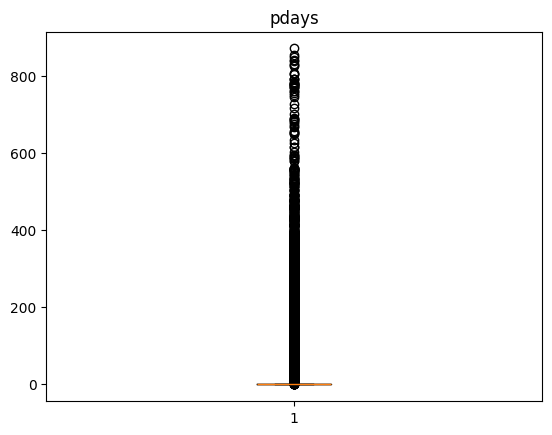

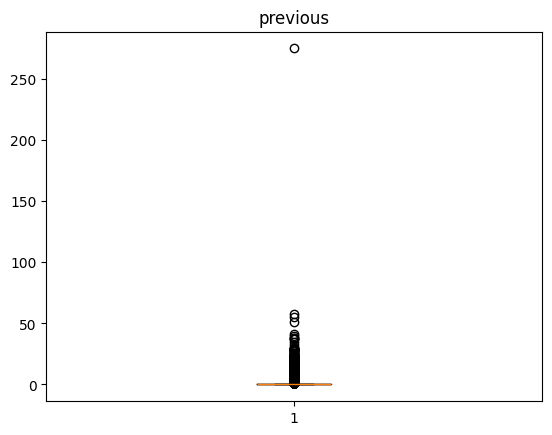

In [6]:
for i in df.columns:
    plt.boxplot(df[i])
    plt.title(i)
    plt.show()

In [7]:
data.duplicated().sum()

np.int64(0)

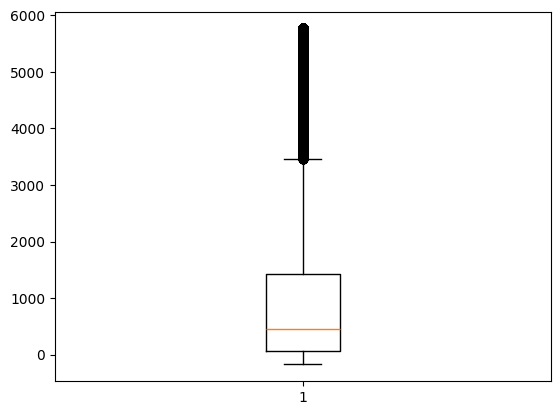

In [8]:
lower=data['balance'].quantile(0.05)
upper=data['balance'].quantile(0.95)
data["balance"]=data["balance"].clip(lower,upper)
plt.boxplot(data["balance"])
plt.show()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,26,blue-collar,single,secondary,yes,-172,no,yes,cellular,7,jul,299,3,-1,0,unknown,no
1,49,management,married,tertiary,yes,-172,no,yes,cellular,21,jul,206,1,-1,0,unknown,no
2,60,management,divorced,tertiary,no,-172,yes,no,cellular,18,may,242,6,-1,0,unknown,no
3,43,management,married,tertiary,yes,-172,yes,no,unknown,29,may,386,2,-1,0,unknown,no
4,57,self-employed,married,tertiary,yes,-172,yes,yes,unknown,9,may,153,1,-1,0,unknown,no


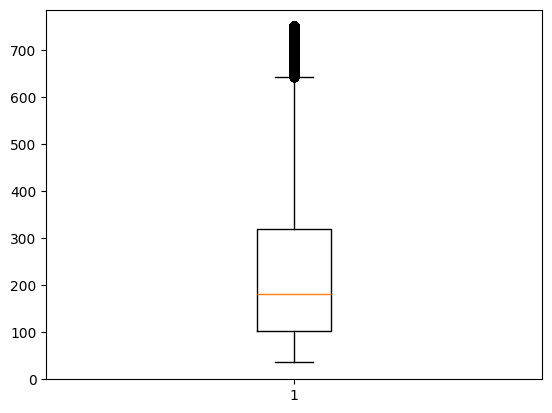

In [9]:
lower=data['duration'].quantile(0.05)
upper=data['duration'].quantile(0.95)   
data["duration"]=data["duration"].clip(lower,upper)
plt.boxplot(data["duration"])
data.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,26,blue-collar,single,secondary,yes,-172,no,yes,cellular,7,jul,299,3,-1,0,unknown,no
1,49,management,married,tertiary,yes,-172,no,yes,cellular,21,jul,206,1,-1,0,unknown,no
2,60,management,divorced,tertiary,no,-172,yes,no,cellular,18,may,242,6,-1,0,unknown,no
3,43,management,married,tertiary,yes,-172,yes,no,unknown,29,may,386,2,-1,0,unknown,no
4,57,self-employed,married,tertiary,yes,-172,yes,yes,unknown,9,may,153,1,-1,0,unknown,no


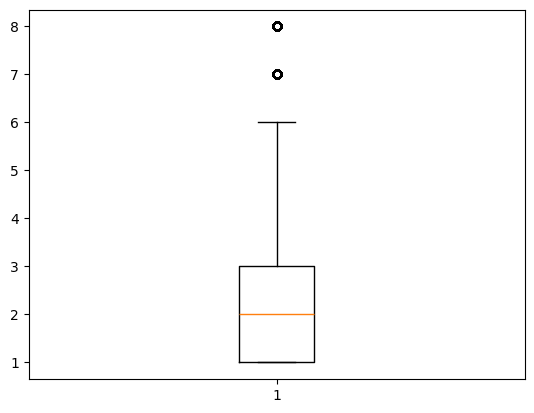

In [10]:
lower=data['campaign'].quantile(0.05)
upper=data['campaign'].quantile(0.95)
data["campaign"]=data["campaign"].clip(lower,upper)
plt.boxplot(data["campaign"])
data.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,26,blue-collar,single,secondary,yes,-172,no,yes,cellular,7,jul,299,3,-1,0,unknown,no
1,49,management,married,tertiary,yes,-172,no,yes,cellular,21,jul,206,1,-1,0,unknown,no
2,60,management,divorced,tertiary,no,-172,yes,no,cellular,18,may,242,6,-1,0,unknown,no
3,43,management,married,tertiary,yes,-172,yes,no,unknown,29,may,386,2,-1,0,unknown,no
4,57,self-employed,married,tertiary,yes,-172,yes,yes,unknown,9,may,153,1,-1,0,unknown,no


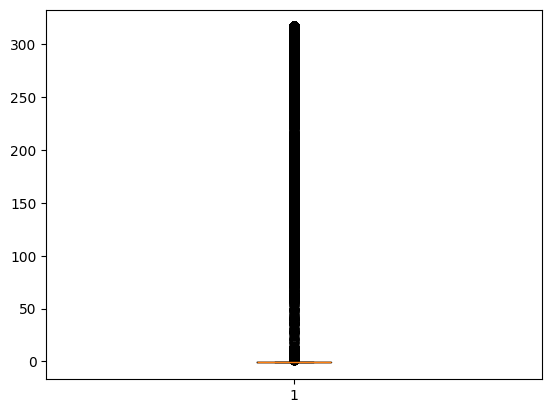

In [11]:
upper=data['pdays'].quantile(0.95)
data["pdays"]=data["pdays"].clip(upper=upper)
plt.boxplot(data["pdays"])
data.head()


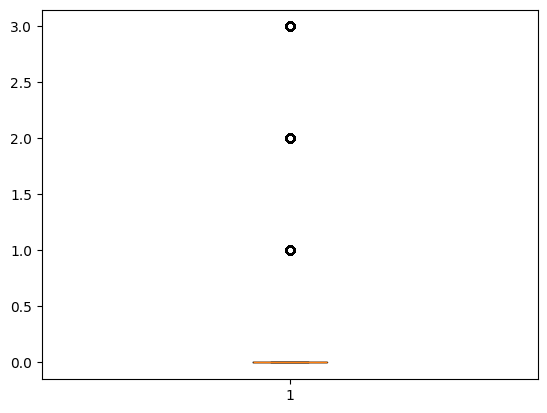

In [12]:
upper=data['previous'].quantile(0.95)
data["previous"]=data["previous"].clip(upper=upper)
plt.boxplot(data["previous"])
plt.show()

In [13]:
data

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,26,blue-collar,single,secondary,yes,-172,no,yes,cellular,7,jul,299,3,-1,0,unknown,no
1,49,management,married,tertiary,yes,-172,no,yes,cellular,21,jul,206,1,-1,0,unknown,no
2,60,management,divorced,tertiary,no,-172,yes,no,cellular,18,may,242,6,-1,0,unknown,no
3,43,management,married,tertiary,yes,-172,yes,no,unknown,29,may,386,2,-1,0,unknown,no
4,57,self-employed,married,tertiary,yes,-172,yes,yes,unknown,9,may,153,1,-1,0,unknown,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,60,retired,married,primary,no,5768,no,no,cellular,6,oct,205,1,-1,0,unknown,no
45207,84,retired,married,secondary,no,5768,no,no,telephone,28,dec,679,1,313,2,other,yes
45208,84,retired,married,secondary,no,5768,no,no,telephone,1,apr,390,1,94,3,success,yes
45209,59,management,married,tertiary,no,5768,no,no,telephone,20,nov,145,5,-1,0,unknown,no


In [14]:
categorical_cols=data.select_dtypes(include=["object"])
categorical_cols

,job,marital,education,default,housing,loan,contact,month,poutcome,y
0,blue-collar,single,secondary,yes,no,yes,cellular,jul,unknown,no
1,management,married,tertiary,yes,no,yes,cellular,jul,unknown,no
2,management,divorced,tertiary,no,yes,no,cellular,may,unknown,no
3,management,married,tertiary,yes,yes,no,unknown,may,unknown,no
4,self-employed,married,tertiary,yes,yes,yes,unknown,may,unknown,no
...,...,...,...,...,...,...,...,...,...,...
45206,retired,married,primary,no,no,no,cellular,oct,unknown,no
45207,retired,married,secondary,no,no,no,telephone,dec,other,yes
45208,retired,married,secondary,no,no,no,telephone,apr,success,yes
45209,management,married,tertiary,no,no,no,telephone,nov,unknown,no


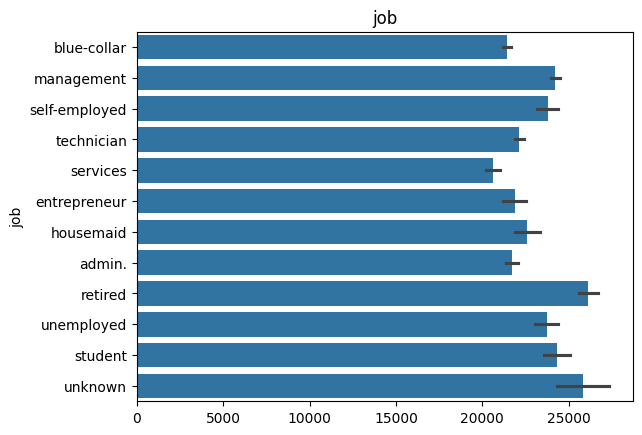

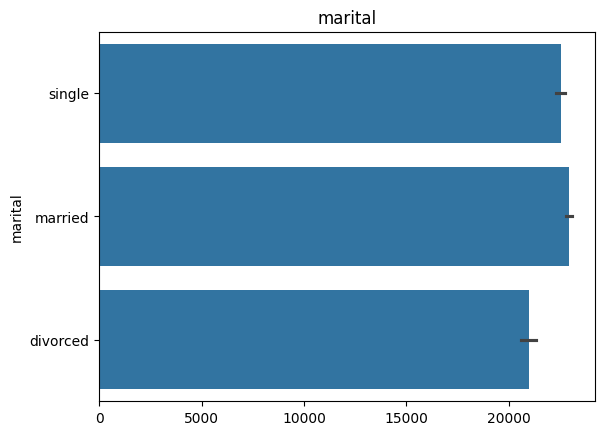

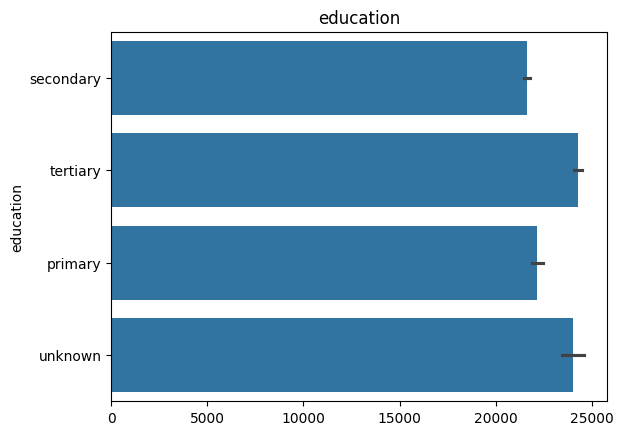

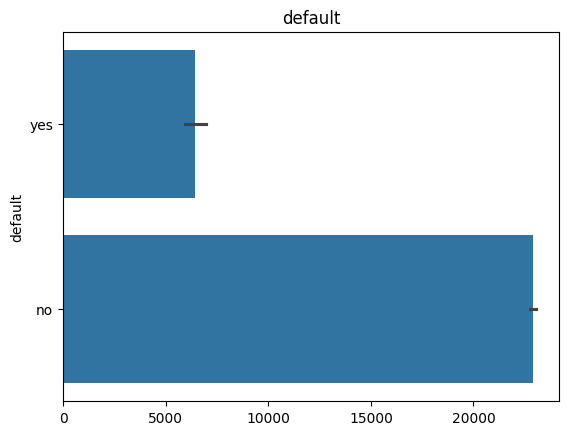

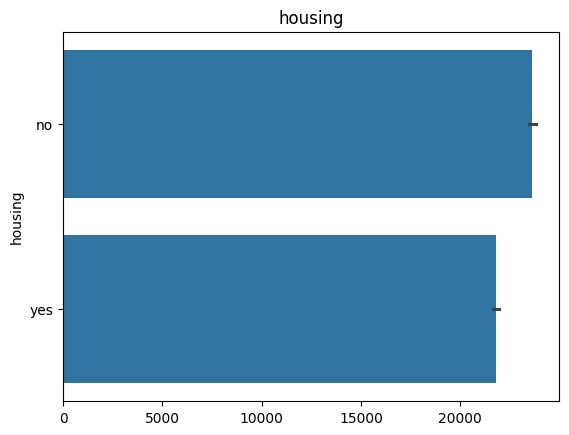

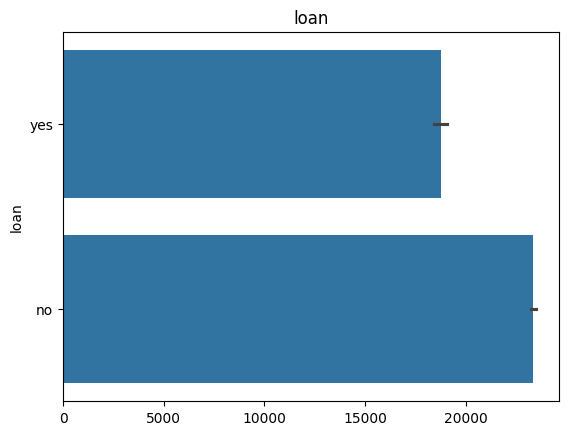

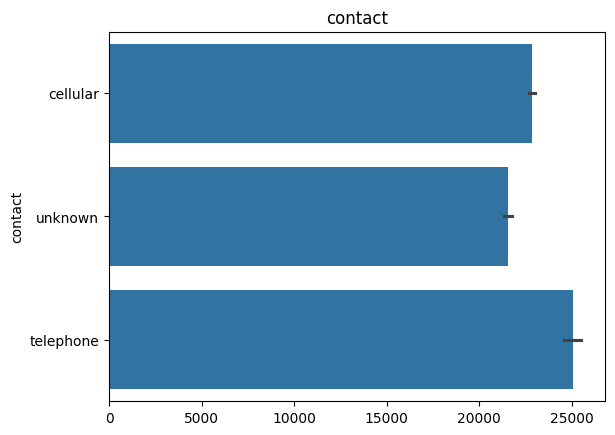

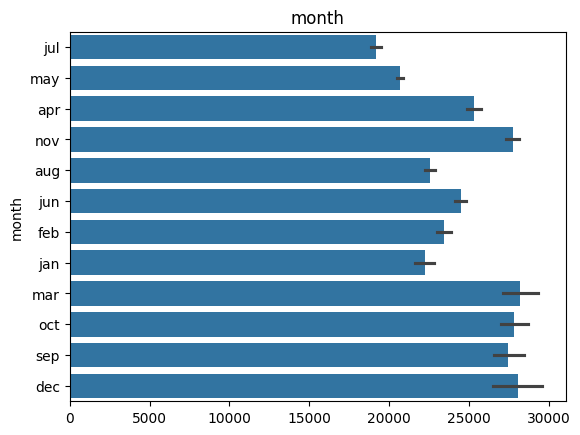

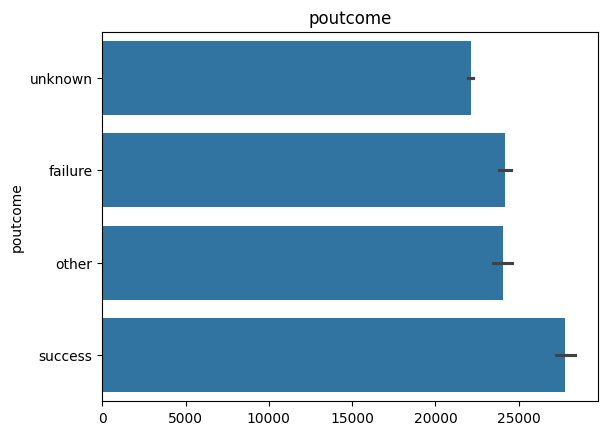

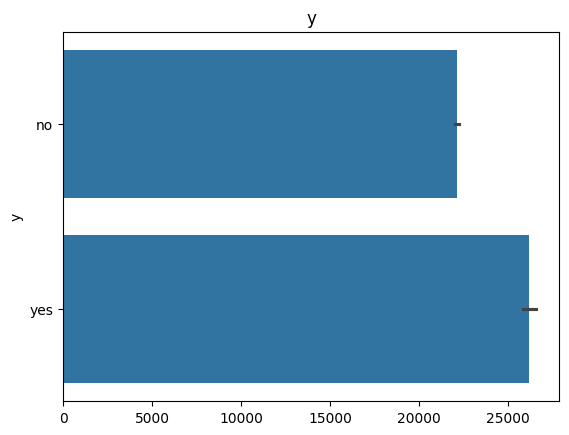

In [15]:
import seaborn as sns
for col in categorical_cols.columns:
    sns.barplot(categorical_cols[col])
    plt.title(col)
    plt.show()

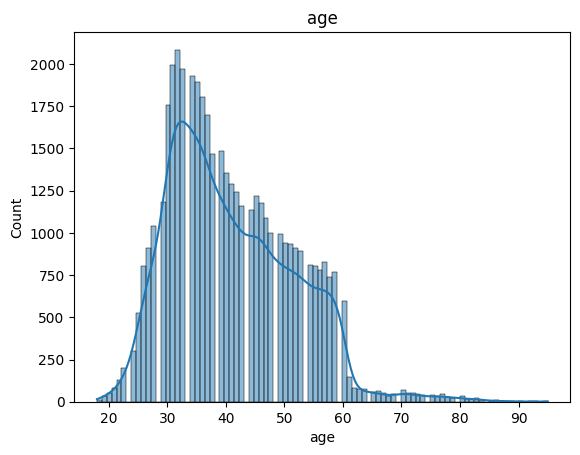

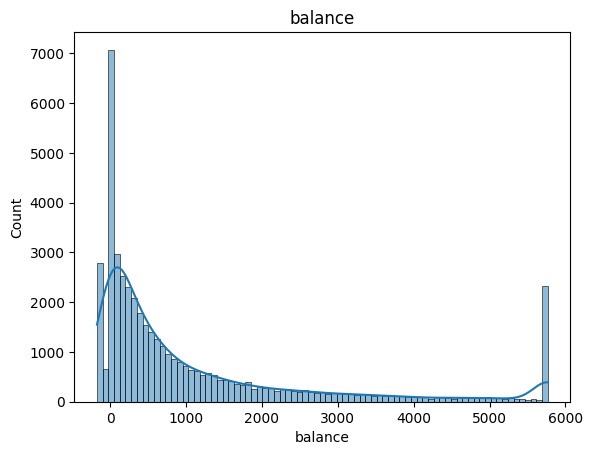

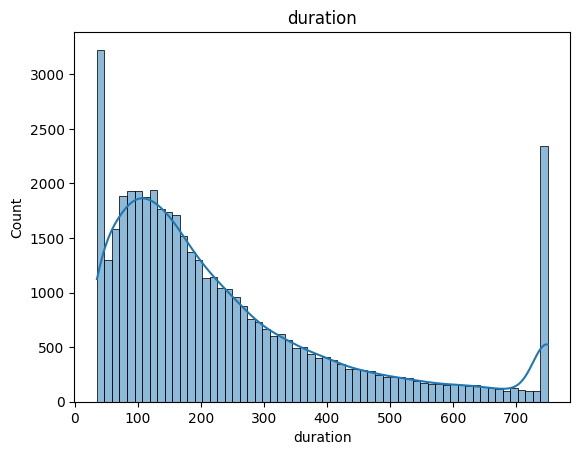

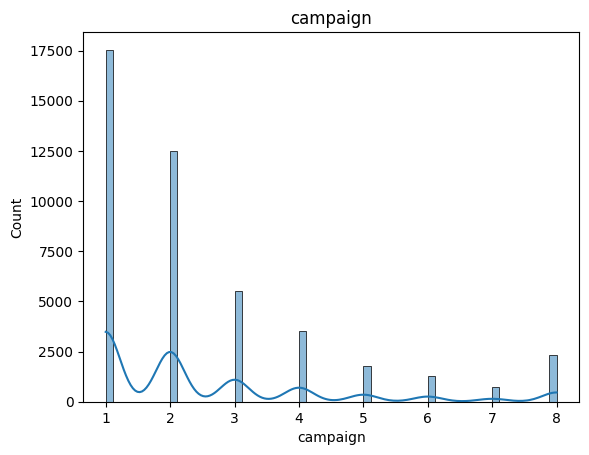

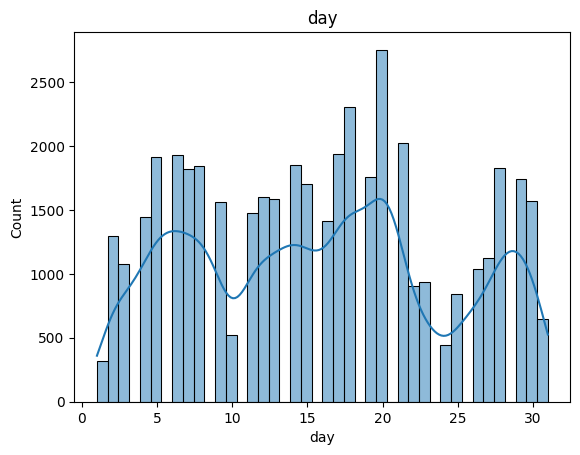

In [16]:
numeric_cols=data[['age','balance','duration','campaign','day']]
numeric_cols
for col in numeric_cols.columns:
    sns.histplot(numeric_cols[col],kde=True)
    plt.title(col)
    plt.show()


(array([ 2276.,    18.,    51.,   123.,   331.,  5579.,  9538., 11308.,
         8561.,  7426.]),
 array([0.        , 0.86896327, 1.73792655, 2.60688982, 3.4758531 ,
        4.34481637, 5.21377965, 6.08274292, 6.9517062 , 7.82066947,
        8.68963275]),
 <BarContainer object of 10 artists>)

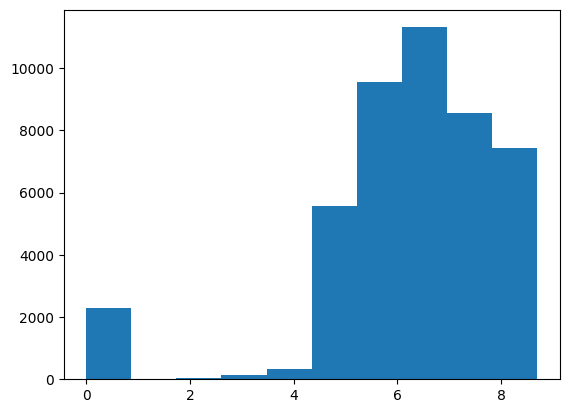

In [17]:
data['balance']=np.log(data['balance'] + np.abs(np.min(data['balance'])) + 1)
plt.hist(data['balance'])

In [18]:
data=pd.get_dummies(data,drop_first=True).astype('float64')
data.head()

,age,balance,day,duration,campaign,pdays,previous,job_blue-collar,job_entrepreneur,job_housemaid,...,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_other,poutcome_success,poutcome_unknown,y_yes
0,26.0,0.0,7.0,299.0,3.0,-1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,49.0,0.0,21.0,206.0,1.0,-1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,60.0,0.0,18.0,242.0,6.0,-1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,43.0,0.0,29.0,386.0,2.0,-1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,57.0,0.0,9.0,153.0,1.0,-1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [19]:
data=data.rename(columns={"y_yes":"target"})
data.head()

,age,balance,day,duration,campaign,pdays,previous,job_blue-collar,job_entrepreneur,job_housemaid,...,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_other,poutcome_success,poutcome_unknown,target
0,26.0,0.0,7.0,299.0,3.0,-1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,49.0,0.0,21.0,206.0,1.0,-1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,60.0,0.0,18.0,242.0,6.0,-1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,43.0,0.0,29.0,386.0,2.0,-1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,57.0,0.0,9.0,153.0,1.0,-1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [20]:
one_hot=OneHotEncoder(drop='first')
dataa=one_hot.fit_transform(data[['day']]).toarray()

In [21]:
columns=one_hot.get_feature_names_out(['day'])
columns

array(['day_2.0', 'day_3.0', 'day_4.0', 'day_5.0', 'day_6.0', 'day_7.0',
       'day_8.0', 'day_9.0', 'day_10.0', 'day_11.0', 'day_12.0',
       'day_13.0', 'day_14.0', 'day_15.0', 'day_16.0', 'day_17.0',
       'day_18.0', 'day_19.0', 'day_20.0', 'day_21.0', 'day_22.0',
       'day_23.0', 'day_24.0', 'day_25.0', 'day_26.0', 'day_27.0',
       'day_28.0', 'day_29.0', 'day_30.0', 'day_31.0'], dtype=object)

In [22]:
data.drop('day',axis=1,inplace=True)
data.head()

,age,balance,duration,campaign,pdays,previous,job_blue-collar,job_entrepreneur,job_housemaid,job_management,...,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_other,poutcome_success,poutcome_unknown,target
0,26.0,0.0,299.0,3.0,-1.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,49.0,0.0,206.0,1.0,-1.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,60.0,0.0,242.0,6.0,-1.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,43.0,0.0,386.0,2.0,-1.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,57.0,0.0,153.0,1.0,-1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [23]:
data=pd.concat([data,pd.DataFrame(dataa,columns=columns)],axis=1)
data

,age,balance,duration,campaign,pdays,previous,job_blue-collar,job_entrepreneur,job_housemaid,job_management,...,day_22.0,day_23.0,day_24.0,day_25.0,day_26.0,day_27.0,day_28.0,day_29.0,day_30.0,day_31.0
0,26.0,0.000000,299.0,3.0,-1.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,49.0,0.000000,206.0,1.0,-1.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,60.0,0.000000,242.0,6.0,-1.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,43.0,0.000000,386.0,2.0,-1.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,57.0,0.000000,153.0,1.0,-1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,60.0,8.689633,205.0,1.0,-1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
45207,84.0,8.689633,679.0,1.0,313.0,2.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
45208,84.0,8.689633,390.0,1.0,94.0,3.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
45209,59.0,8.689633,145.0,5.0,-1.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [24]:
data['pdays']=np.where(data['pdays']>=0,1,0)
data.head()

,age,balance,duration,campaign,pdays,previous,job_blue-collar,job_entrepreneur,job_housemaid,job_management,...,day_22.0,day_23.0,day_24.0,day_25.0,day_26.0,day_27.0,day_28.0,day_29.0,day_30.0,day_31.0
0,26.0,0.0,299.0,3.0,0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,49.0,0.0,206.0,1.0,0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,60.0,0.0,242.0,6.0,0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,43.0,0.0,386.0,2.0,0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,57.0,0.0,153.0,1.0,0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [25]:
data['pdays'].value_counts()

pdays
0    36954
1     8257
Name: count, dtype: int64

In [26]:
X=data.drop('target',axis=1)
y=data['target']

In [27]:
from imblearn.over_sampling import SMOTE
smote=SMOTE(random_state=42)
X_resampled,y_resampled=smote.fit_resample(X,y)
print(y.value_counts())
print(y_resampled.value_counts())

target
0.0    39922
1.0     5289
Name: count, dtype: int64
target
0.0    39922
1.0    39922
Name: count, dtype: int64


In [28]:
X_resampled

,age,balance,duration,campaign,pdays,previous,job_blue-collar,job_entrepreneur,job_housemaid,job_management,...,day_22.0,day_23.0,day_24.0,day_25.0,day_26.0,day_27.0,day_28.0,day_29.0,day_30.0,day_31.0
0,26.000000,0.000000,299.000000,3.000000,0,0.000000,1.000000,0.000000,0.0,0.0,...,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.0
1,49.000000,0.000000,206.000000,1.000000,0,0.000000,0.000000,0.000000,0.0,1.0,...,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.0
2,60.000000,0.000000,242.000000,6.000000,0,0.000000,0.000000,0.000000,0.0,1.0,...,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.0
3,43.000000,0.000000,386.000000,2.000000,0,0.000000,0.000000,0.000000,0.0,1.0,...,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.0,1.000000,0.0,0.0
4,57.000000,0.000000,153.000000,1.000000,0,0.000000,0.000000,0.000000,0.0,0.0,...,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79839,28.940025,8.311185,705.000000,1.000000,0,0.000000,0.470012,0.000000,0.0,0.0,...,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.0
79840,52.451258,2.386375,531.292449,1.451258,0,0.000000,0.451258,0.548742,0.0,0.0,...,0.451258,0.0,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.0
79841,38.000000,7.113838,163.552887,1.776443,1,2.223557,0.223557,0.000000,0.0,0.0,...,0.000000,0.0,0.0,0.000000,0.0,0.776443,0.0,0.000000,0.0,0.0
79842,51.000000,6.009374,371.497362,3.492085,0,0.000000,0.000000,0.000000,0.0,0.0,...,0.000000,0.0,0.0,0.497362,0.0,0.000000,0.0,0.000000,0.0,0.0


In [29]:
X_train,X_test,y_train,y_test=train_test_split(X_resampled,y_resampled,test_size=0.2,random_state=42)

In [30]:
numeric_train=X_train[['age','balance','duration','campaign','previous']]
categori=[col for col in X_train.columns if col not in numeric_train.columns] 
categorical_train=X_train[categori]
categorical_train.shape

(63875, 66)

In [31]:
numeric_train

,age,balance,duration,campaign,previous
76180,38.965870,6.079837,174.982935,1.982935,2.017065
36038,40.000000,7.603399,213.000000,4.000000,0.000000
41791,39.000000,8.434464,35.000000,4.000000,1.000000
66185,25.606469,5.970834,751.000000,1.000000,1.787061
17247,81.000000,6.030685,131.000000,1.000000,0.000000
...,...,...,...,...,...
6265,48.000000,5.153292,107.000000,1.000000,0.000000
54886,32.884738,6.469431,475.115262,1.961579,0.000000
76820,31.000000,7.515858,277.338384,4.000000,0.887205
860,31.000000,0.000000,157.000000,1.000000,0.000000


In [32]:
numeric_test=X_test[['age','balance','duration','campaign','previous']]
categorii=[col for col in X_test.columns if col not in numeric_test.columns] 
categorical_test=X_test[categorii]
categorical_test.shape

(15969, 66)

In [33]:
scaler=StandardScaler()
numeric_scaled=scaler.fit_transform(numeric_train)
numeric_scaled_test=scaler.transform(numeric_test)
x_train=pd.concat([pd.DataFrame(numeric_scaled, columns=numeric_train.columns,index=X_train.index), categorical_train], axis=1)

In [34]:
x_test=pd.concat([pd.DataFrame(numeric_scaled_test, columns=numeric_test.columns,index=X_test.index), categorical_test], axis=1)

In [35]:
model_decision=DecisionTreeClassifier()
model_decision.fit(x_train,y_train)
y_pred_train=model_decision.predict(x_train)
y_pred_test=model_decision.predict(x_test)
accuracy_train=accuracy_score(y_train,y_pred_train)
print("Training Accuracy:",accuracy_train)
precision_train=precision_score(y_train,y_pred_train)
print("Training Precision:",precision_train)
accuracy=accuracy_score(y_test,y_pred_test)
print("Accuracy:",accuracy)
precision=precision_score(y_test,y_pred_test)
print("Precision:",precision)


Training Accuracy: 1.0
Training Precision: 1.0
Accuracy: 0.9272340159058176
Precision: 0.9241370747454681


In [36]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth':[None,10,20,30],
    'min_samples_split':[5,10],
    'min_samples_leaf': [2,4]
}

grid_decision=GridSearchCV(estimator=model_decision,param_grid=param_grid,cv=3)
grid_decision.fit(x_train,y_train)

,estimator,DecisionTreeClassifier()
,param_grid,"{'criterion': ['gini', 'entropy'], 'max_depth': [None, 10, ...], 'min_samples_leaf': [2, 4], 'min_samples_split': [5, 10]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'entropy'


In [38]:
print("Best Parameters:",grid_decision.best_params_)
best_decision=grid_decision.best_estimator_
y_pred_train_grid_decision=best_decision.predict(x_train)
y_pred_test_grid_decision=best_decision.predict(x_test)
accuracy_train_grid_decision=accuracy_score(y_train,y_pred_train_grid_decision)
accuracy_test_grid_decision=accuracy_score(y_test,y_pred_test_grid_decision)
print("Training Accuracy after Grid Search:",accuracy_train_grid_decision)
print("Testing Accuracy after Grid Search:",accuracy_test_grid_decision)
precision_train_grid_decision=precision_score(y_train,y_pred_train_grid_decision)
precision_test_grid_decision=precision_score(y_test,y_pred_test_grid_decision)  
print("Training Precision after Grid Search:",precision_train_grid_decision)
print("Testing Precision after Grid Search:",precision_test_grid_decision)
recall_train_grid_decision=recall_score(y_train,y_pred_train_grid_decision)
recall_test_grid_decision=recall_score(y_test,y_pred_test_grid_decision)
print("Training Recall after Grid Search:",recall_train_grid_decision)
print("Testing Recall after Grid Search:",recall_test_grid_decision)
f1_train_grid_decision=f1_score(y_train,y_pred_train_grid_decision)
f1_test_grid_decision=f1_score(y_test,y_pred_test_grid_decision)
print("Training F1 Score after Grid Search:",f1_train_grid_decision)
print("Testing F1 Score after Grid Search:",f1_test_grid_decision)
TN, FP, FN, TP = confusion_matrix(y_train, y_pred_train_grid_decision).ravel()
specificity=TN/(TN+FP)
print("Specificity Training:",specificity)
TN, FP, FN, TP = confusion_matrix(y_test, y_pred_test_grid_decision).ravel()
specificity=TN/(TN+FP)
print("Specificity Testing:",specificity)


Best Parameters: {'criterion': 'entropy', 'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 5}
Training Accuracy after Grid Search: 0.9679060665362035
Testing Accuracy after Grid Search: 0.9353747886530153
Training Precision after Grid Search: 0.9657376231450305
Testing Precision after Grid Search: 0.9331757093081134
Training Recall after Grid Search: 0.9702142320220496
Testing Recall after Grid Search: 0.9380785589191893
Training F1 Score after Grid Search: 0.9679707518280107
Testing F1 Score after Grid Search: 0.9356207111665626
Specificity Training: 0.9655992737972267
Specificity Testing: 0.9326645768025078


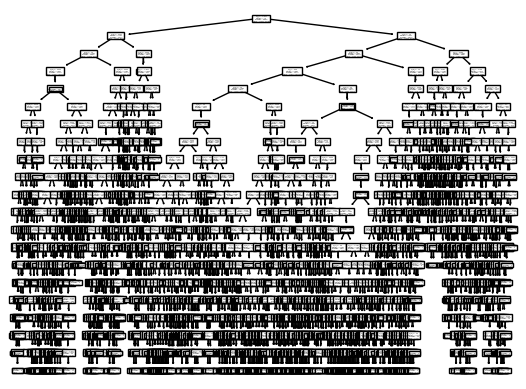

In [39]:
from sklearn.tree import plot_tree
plot_tree(grid_decision.best_estimator_)
plt.show()

In [40]:
df_imp = pd.DataFrame({
    'Feature': X.columns,
    'Importance': grid_decision.best_estimator_.feature_importances_
})

df_imp = df_imp.sort_values(by='Importance', ascending=False)

print(df_imp.head(10))

             Feature  Importance
2           duration    0.305371
23       housing_yes    0.146676
39  poutcome_success    0.127247
26   contact_unknown    0.083689
27         month_aug    0.030232
31         month_jul    0.028519
34         month_may    0.024775
0                age    0.022658
1            balance    0.019788
29         month_feb    0.019753


In [41]:
RF=RandomForestClassifier()
RF.fit(x_train,y_train)
y_pred_train_rf=RF.predict(x_train)
y_pred_test_rf=RF.predict(x_test)
accuracy_train_rf=accuracy_score(y_train,y_pred_train_rf)
accuracy_test_rf=accuracy_score(y_test,y_pred_test_rf)
print("Training Accuracy for Random Forest:",accuracy_train_rf)
print("Testing Accuracy for Random Forest:",accuracy_test_rf)
precision_train_rf=precision_score(y_train,y_pred_train_rf)
precision_test_rf=precision_score(y_test,y_pred_test_rf)
print("Training Precision for Random Forest:",precision_train_rf)
print("Testing Precision for Random Forest:",precision_test_rf)


Training Accuracy for Random Forest: 1.0
Testing Accuracy for Random Forest: 0.9516563341474106
Training Precision for Random Forest: 1.0
Testing Precision for Random Forest: 0.9670201758923952


In [42]:
RF.estimator

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [43]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20],
    'min_samples_split': [5, 10],
    'min_samples_leaf': [2, 4]
}

rf_grid=GridSearchCV(estimator=RF,param_grid=param_grid,cv=3,n_jobs=-1)
rf_grid.fit(x_train,y_train)
print("Best Parameters for Random Forest:",rf_grid.best_params_)
best_rf=rf_grid.best_estimator_
y_pred_train_rf_grid=best_rf.predict(x_train)
y_pred_test_rf_grid=best_rf.predict(x_test)
accuracy_train_rf_grid=accuracy_score(y_train,y_pred_train_rf_grid)
accuracy_test_rf_grid=accuracy_score(y_test,y_pred_test_rf_grid)
print("Training Accuracy for Random Forest after Grid Search:",accuracy_train_rf_grid)
print("Testing Accuracy for Random Forest after Grid Search:",accuracy_test_rf_grid)
precision_train_rf_grid=precision_score(y_train,y_pred_train_rf_grid)
precision_test_rf_grid=precision_score(y_test,y_pred_test_rf_grid)
print("Training Precision for Random Forest after Grid Search:",precision_train_rf_grid)
print("Testing Precision for Random Forest after Grid Search:",precision_test_rf_grid)
recall_train_rf_grid=recall_score(y_train,y_pred_train_rf_grid)
recall_test_rf_grid=recall_score(y_test,y_pred_test_rf_grid)
print("Training Recall for Random Forest after Grid Search:",recall_train_rf_grid)
print("Testing Recall for Random Forest after Grid Search:",recall_test_rf_grid)
f1_train_rf_grid=f1_score(y_train,y_pred_train_rf_grid)
f1_test_rf_grid=f1_score(y_test,y_pred_test_rf_grid)
print("Training F1 Score for Random Forest after Grid Search:",f1_train_rf_grid)
print("Testing F1 Score for Random Forest after Grid Search:",f1_test_rf_grid)


Best Parameters for Random Forest: {'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}
Training Accuracy for Random Forest after Grid Search: 0.9719765166340509
Testing Accuracy for Random Forest after Grid Search: 0.9507796355438662
Training Precision for Random Forest after Grid Search: 0.980639193671855
Testing Precision for Random Forest after Grid Search: 0.9578252032520326
Training Recall for Random Forest after Grid Search: 0.9629478827361564
Testing Recall for Random Forest after Grid Search: 0.9432074055541656
Training F1 Score for Random Forest after Grid Search: 0.9717130214917825
Testing F1 Score for Random Forest after Grid Search: 0.9504601033656876


In [44]:
pd.DataFrame({
    'Feature': X.columns,
    'Importance': grid_decision.best_estimator_.feature_importances_
}).sort_values(by='Importance', ascending=False).head(10)

,Feature,Importance
2,duration,0.305371
23,housing_yes,0.146676
39,poutcome_success,0.127247
26,contact_unknown,0.083689
27,month_aug,0.030232
31,month_jul,0.028519
34,month_may,0.024775
0,age,0.022658
1,balance,0.019788
29,month_feb,0.019753


In [45]:
xg=XGBClassifier()
xg.fit(x_train,y_train)
y_pred_train_xg=xg.predict(x_train)
y_pred_test_xg=xg.predict(x_test)
accuracy_train_xg=accuracy_score(y_train,y_pred_train_xg)
accuracy_test_xg=accuracy_score(y_test,y_pred_test_xg)
print("Training Accuracy for XGBoost:",accuracy_train_xg)
print("Testing Accuracy for XGBoost:",accuracy_test_xg)
precision_train_xg=precision_score(y_train,y_pred_train_xg)
precision_test_xg=precision_score(y_test,y_pred_test_xg)
print("Training Precision for XGBoost:",precision_train_xg)
print("Testing Precision for XGBoost:",precision_test_xg)
f1_train_xg=f1_score(y_train,y_pred_train_xg)
f1_test_xg=f1_score(y_test,y_pred_test_xg)
print("Training F1 Score for XGBoost:",f1_train_xg)
print("Testing F1 Score for XGBoost:",f1_test_xg)
recall_train_xg=recall_score(y_train,y_pred_train_xg)
recall_test_xg=recall_score(y_test,y_pred_test_xg)
print("Training Recall for XGBoost:",recall_train_xg)
print("Testing Recall for XGBoost:",recall_test_xg)

Training Accuracy for XGBoost: 0.9678904109589042
Testing Accuracy for XGBoost: 0.9463961425261445
Training Precision for XGBoost: 0.9778026547257317
Testing Precision for XGBoost: 0.9547655453618756
Training F1 Score for XGBoost: 0.967543873530296
Testing F1 Score for XGBoost: 0.9459664183815175
Training Recall for XGBoost: 0.9574981207717365
Testing Recall for XGBoost: 0.9373279959969978


In [46]:
sv=SVC()
sv.fit(x_train,y_train)
y_pred_train_sv=sv.predict(x_train)
y_pred_test_sv=sv.predict(x_test)
accuracy_train_sv=accuracy_score(y_train,y_pred_train_sv)
accuracy_test_sv=accuracy_score(y_test,y_pred_test_sv)
print("Training Accuracy for SVM:",accuracy_train_sv)
print("Testing Accuracy for SVM:",accuracy_test_sv)
precision_train_sv=precision_score(y_train,y_pred_train_sv)
precision_test_sv=precision_score(y_test,y_pred_test_sv)
print("Training Precision for SVM:",precision_train_sv)
print("Testing Precision for SVM:",precision_test_sv)


Training Accuracy for SVM: 0.948054794520548
Testing Accuracy for SVM: 0.9373786711754023
Training Precision for SVM: 0.9409679408138101
Testing Precision for SVM: 0.9310897435897436


In [47]:
recall_train_sv=recall_score(y_train,y_pred_train_sv)
recall_test_sv=recall_score(y_test,y_pred_test_sv)
print("Training Recall for SVM:",recall_train_sv)
print("Testing Recall for SVM:",recall_test_sv)
f1_train_sv=f1_score(y_train,y_pred_train_sv)
f1_test_sv=f1_score(y_test,y_pred_test_sv)
print("Training F1 Score for SVM:",f1_train_sv)
print("Testing F1 Score for SVM:",f1_test_sv)


Training Recall for SVM: 0.9560573791029817
Testing Recall for SVM: 0.9448336252189142
Training F1 Score for SVM: 0.9484526472781506
Testing F1 Score for SVM: 0.9379113373897926


In [48]:
import pickle
pickle.dump(best_rf,open("best_rf_model.pkl","wb"))
pickle.dump(scaler,open("scaler.pkl","wb"))


In [49]:
pickle.dump(one_hot,open("one_hot_encoder.pkl","wb"))

In [53]:
pickle.dump(X.columns,open('columns.pkl','wb'))
pickle.dump(numeric_train,open('numeric_columns.pkl','wb'))
pickle.dump(categorical_train,open('categorical_columns.pkl','wb'))

In [56]:
pickle.dump((lower_bound,upper_bound),open("bound.pkl","wb"))